In [1]:
# avg_pred_core8_16mpa.py
import os, gc, math, itertools
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset, ConcatDataset
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import random
import gc
import matplotlib as mpl
import os, json, csv
from itertools import combinations
from collections import defaultdict
from matplotlib import gridspec, colors
import piq
import pickle

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
class NumpyDataset(Dataset):
    def __init__(self, x_path, y_path):
        self.x = np.load(x_path)
        self.y = np.load(y_path)
    
    def __len__(self):
        return self.x.shape[0]
    
    def __getitem__(self, idx):
        x_full = self.x[idx]
        main_x = torch.tensor(x_full[:11, :, :], dtype=torch.float32)
        time_enc = torch.tensor(x_full[11:12, :, :], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return main_x, time_enc, y

class ConvBlock(nn.Module):
    def __init__(self, in_channels, time_channels, out_channels, kernel_size=3, activation=nn.ReLU()):
        super(ConvBlock, self).__init__()
        padding = kernel_size // 2  # same padding for odd kernel sizes
        self.activation = activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.time_conv = nn.Conv2d(time_channels, out_channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        
    def forward(self, x, time_emb):
        # Resize time embedding if its spatial dimensions differ from x
        if time_emb.shape[-2:] != x.shape[-2:]:
            time_emb = F.interpolate(time_emb, size=x.shape[-2:], mode='bilinear', align_corners=False)
        out_x = self.activation(self.conv1(x))
        out_time = self.activation(self.time_conv(time_emb))
        out = out_x + out_time
        out = self.activation(self.conv2(out))
        return out

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, time_channels, out_channels):
        super(EncoderBlock, self).__init__()
        self.conv_block = ConvBlock(in_channels, time_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
    def forward(self, x, time_emb):
        x_conv = self.conv_block(x, time_emb)
        x_pooled = self.pool(x_conv)
        return x_conv, x_pooled

def crop_tensor(skip, target):
    diffY = skip.size(2) - target.size(2)
    diffX = skip.size(3) - target.size(3)
    return skip[:, :, diffY//2 : skip.size(2) - (diffY - diffY//2), 
                   diffX//2 : skip.size(3) - (diffX - diffX//2)]

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, time_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv_block = ConvBlock(in_channels + skip_channels, time_channels, out_channels)
        
    def forward(self, x, skip, time_emb):
        x = self.upsample(x)
        if x.size(2) != skip.size(2) or x.size(3) != skip.size(3):
            skip = crop_tensor(skip, x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv_block(x, time_emb)
        return x

class ConditionalUNet(nn.Module):
    def __init__(self, input_channels=11, time_channels=1, base_filters=64):
        super(ConditionalUNet, self).__init__()
        # Encoder path
        self.enc1 = EncoderBlock(input_channels, time_channels, base_filters)          # 8 -> 64
        self.enc2 = EncoderBlock(base_filters, time_channels, base_filters * 2)          # 64 -> 128
        self.enc3 = EncoderBlock(base_filters * 2, time_channels, base_filters * 4)      # 128 -> 256
        self.enc4 = EncoderBlock(base_filters * 4, time_channels, base_filters * 8)      # 256 -> 512
        
        self.bottleneck = ConvBlock(base_filters * 8, time_channels, base_filters * 16)  # 512 -> 1024
        
        self.dec1 = DecoderBlock(base_filters * 16, base_filters * 8, time_channels, base_filters * 8)  # (1024+512) -> 512
        self.dec2 = DecoderBlock(base_filters * 8, base_filters * 4, time_channels, base_filters * 4)   # (512+256) -> 256
        self.dec3 = DecoderBlock(base_filters * 4, base_filters * 2, time_channels, base_filters * 2)   # (256+128) -> 128
        self.dec4 = DecoderBlock(base_filters * 2, base_filters, time_channels, base_filters)           # (128+64) -> 64
        
        self.out_conv = nn.Conv2d(base_filters, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x, time_emb):
        # Encoder
        c1, p1 = self.enc1(x, time_emb)   # c1: (B, 64, 247,247); p1: (B, 64, 123,123)
        c2, p2 = self.enc2(p1, time_emb)    # c2: (B, 128, 123,123); p2: (B, 128, 61,61)
        c3, p3 = self.enc3(p2, time_emb)    # c3: (B, 256, 61,61);  p3: (B, 256, 30,30)
        c4, p4 = self.enc4(p3, time_emb)    # c4: (B, 512, 30,30);  p4: (B, 512, 15,15)
        
        bn = self.bottleneck(p4, time_emb)  # bn: (B, 1024, 15,15)
        
        # Decoder
        d1 = self.dec1(bn, c4, time_emb)    # d1: (B, 512, 30,30)
        d2 = self.dec2(d1, c3, time_emb)     # d2: (B, 256, 60,60)
        d3 = self.dec3(d2, c2, time_emb)     # d3: (B, 128, 120,120)
        d4 = self.dec4(d3, c1, time_emb)     # d4: (B, 64, 240,240)
        
        out = self.out_conv(d4)             # (B, 1, 240,240)
        out = self.sigmoid(out)
        # Resize the output to match the original input size (e.g., 247x247)
        out = F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return out

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cuda', model_save_path="best_model.pth"):
    model.to(device)
    best_val_loss = float('inf')
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for main_x, time_enc, y in train_loader:
            main_x, time_enc, y = main_x.to(device), time_enc.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(main_x, time_enc)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * main_x.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for main_x, time_enc, y in val_loader:
                main_x, time_enc, y = main_x.to(device), time_enc.to(device), y.to(device)
                outputs = model(main_x, time_enc)
                loss = criterion(outputs, y)
                val_loss += loss.item() * main_x.size(0)
        val_loss /= len(val_loader.dataset)
        
        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_save_path)
    
    total_time = time.time() - start_time
    print(f"Total training time: {total_time:.2f} seconds")
    return model


In [3]:
total = np.load("training_data/total_8_near_dissociation.npy")
#total = np.load("training_data/total_8_20to0.npy")

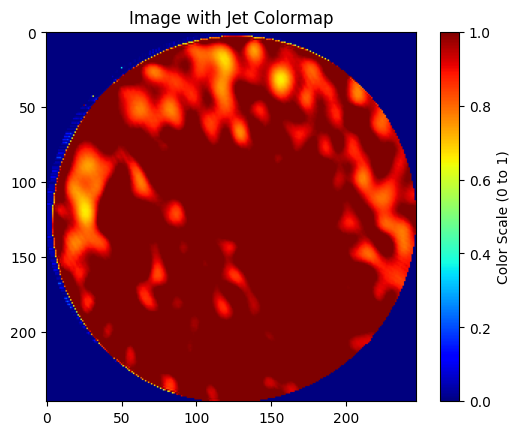

In [4]:
plt.imshow(total[192], cmap='jet', vmin=0, vmax=1)
plt.colorbar(label='Color Scale (0 to 1)')
plt.title('Image with Jet Colormap')
plt.show()

In [5]:
total_final=[]

In [6]:
for i in range(64):
    tmp=total[i:i+64*12:64,:,:,0]
    total_final.append(tmp)


In [7]:
np.shape(total_final)

(64, 12, 247, 247)

In [8]:
total_final=np.array(total_final)

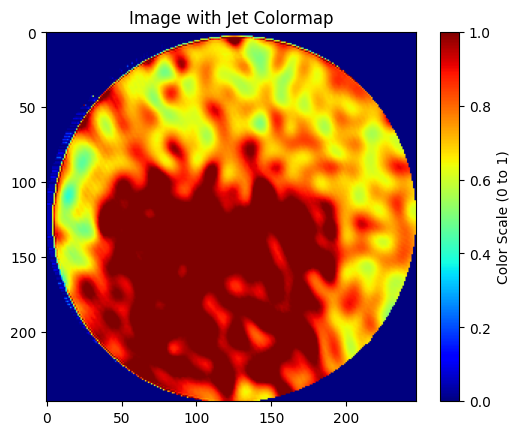

In [9]:
plt.imshow(total_final[1,11], cmap='jet', vmin=0, vmax=1)
plt.colorbar(label='Color Scale (0 to 1)')
plt.title('Image with Jet Colormap')
plt.show()

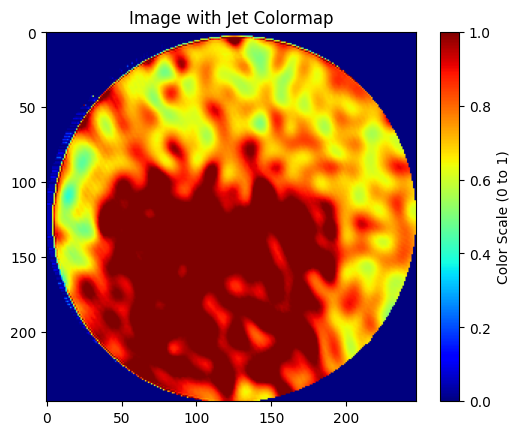

In [10]:
plt.imshow(total_final[1,11], cmap='jet', vmin=0, vmax=1)
plt.colorbar(label='Color Scale (0 to 1)')
plt.title('Image with Jet Colormap')
plt.show()

In [11]:
total_r2=np.ones((64,12))

In [12]:

for i in range(0,64):
    for j in range(0,11):
        ss_res=np.sum((total_final[i,j]-total_final[i,j+1])**2)
        ss_tot=np.sum((total_final[i,j]-total_final[i,j].mean())**2)
        #tmp_r2=r2_score(total_final[i,j],total_final[i,j+1])
        tmp_r2=1-ss_res/ss_tot
        total_r2[i,j+1]=tmp_r2

In [13]:
#total_mae=np.zeros((64,18))

In [14]:
#for i in range(0,64):
#    for j in range(0,17):
#        total_mae[i,j+1]=np.mean(np.abs(total_final[i,j]-total_final[i,j+1]))

In [15]:
#total_r2[20]

In [16]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L", "DejaVu Serif"],  # fallbacks
    "mathtext.fontset": "dejavuserif",   # math text harmonizes with serif
    "axes.unicode_minus": False,         # proper minus sign with serif fonts
    "pdf.fonttype": 42,                  # embed TrueType in vector outputs
    "ps.fonttype": 42,
})

NameError: name 'ax' is not defined

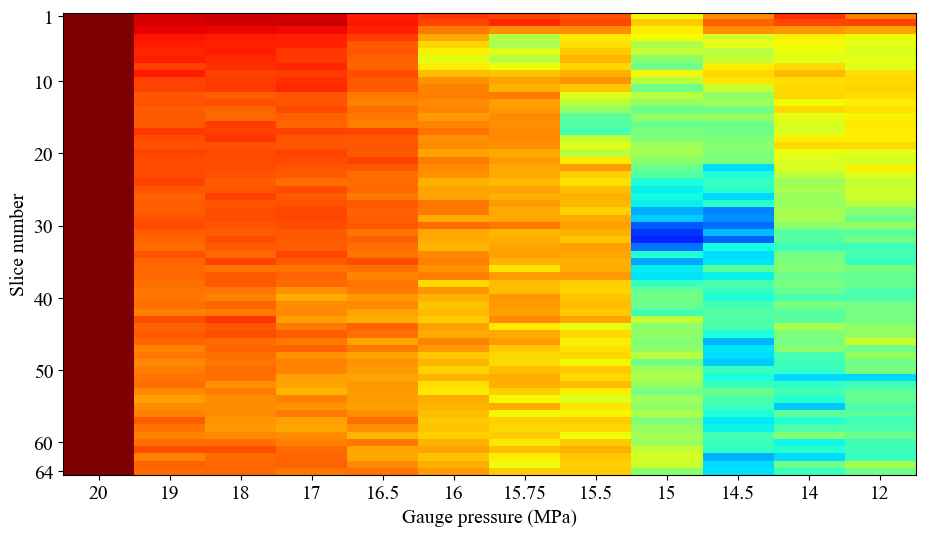

In [17]:
vmin=0.88
vmax=1
r2 = plt.cm.ScalarMappable(norm=colors.Normalize(vmin=vmin, vmax=vmax), cmap='jet')

fig=plt.figure(figsize=(11, 6))
plt.imshow(total_r2, cmap='jet',vmin=vmin, vmax=vmax,aspect='auto')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11],fontsize=14,labels=['20', '19', '18', '17', '16.5', '16', '15.75', '15.5', '15', '14.5', '14', '12'])
plt.yticks([0,9,19,29,39,49,59,63],fontsize=14,labels=['1','10','20','30','40','50','60','64'])
plt.xlabel('Gauge pressure (MPa)',fontsize=14)
plt.ylabel('Slice number',fontsize=14)

avg_r2 = np.nanmean(total_r2)
ax.text(
    0.5, 1.1, f'Average R\u00b2',
    transform=ax.transAxes, ha='center', va='bottom',
    fontsize=18,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

cbar = fig.colorbar(r2, ax=plt.gca())
cbar.ax.set_ylabel(f"R\u00b2",rotation=0,labelpad=15,loc='center',fontsize=14)
fig.subplots_adjust(top=0.92)
plt.savefig("r2_CTimages", dpi=230)
plt.show()

plt.close(fig)

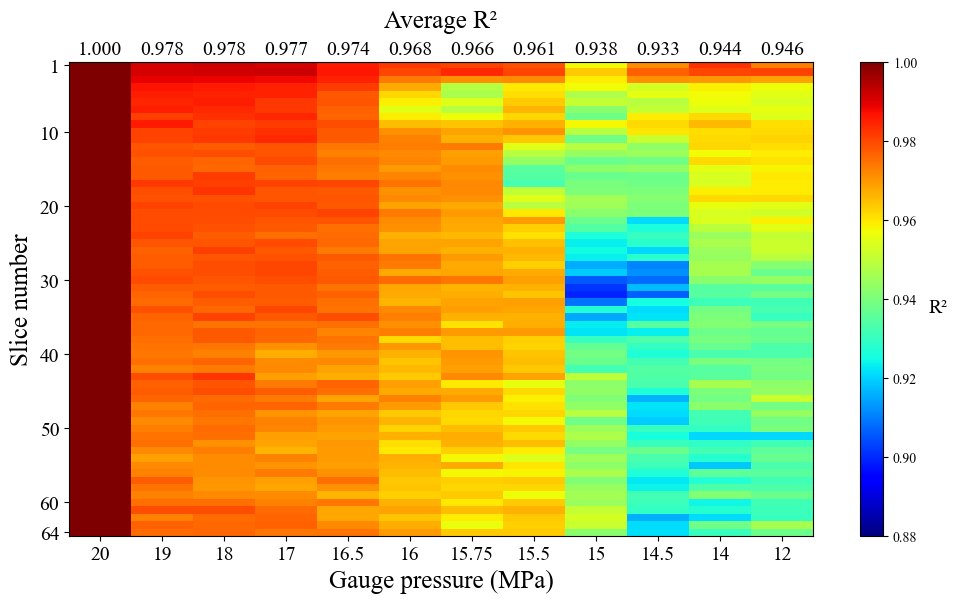

In [36]:
vmin=0.88
vmax=1
r2 = plt.cm.ScalarMappable(norm=colors.Normalize(vmin=vmin, vmax=vmax), cmap='jet')
r2.set_array([])  # avoid warning

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()

im = ax.imshow(total_r2, cmap='jet', vmin=vmin, vmax=vmax, aspect='auto')

# ticks & labels
ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11])
ax.set_xticklabels(['20', '19', '18', '17', '16.5', '16', '15.75', '15.5', '15', '14.5', '14', '12'], fontsize=14)
ax.set_yticks([0,9,19,29,39,49,59,63])
ax.set_yticklabels(['1','10','20','30','40','50','60','64'], fontsize=14)
ax.set_xlabel('Gauge pressure (MPa)', fontsize=18)
ax.set_ylabel('Slice number', fontsize=18)

# --- NEW (A): overall "Average R2" label using ax.text(...) ---
avg_r2 = np.nanmean(total_r2)
ax.text(
    0.5, 1.06, f"Average R\u00b2",
    transform=ax.transAxes, ha='center', va='bottom',
    fontsize=18,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2),
    clip_on=False
)

# --- NEW (B): per-column average R² labels (as before) ---
col_means = np.nanmean(total_r2, axis=0)  # shape (12,)
for x, m in enumerate(col_means):
    ax.text(
        x, -1.0, f'{m:.3f}',
        ha='center', va='bottom', fontsize=14, color='black',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
        clip_on=False
    )

# colorbar
cbar = fig.colorbar(r2, ax=ax)
cbar.ax.set_ylabel("R\u00b2", rotation=0, labelpad=15, loc='center', fontsize=14)

# headroom so labels don't get clipped
fig.subplots_adjust(top=0.90)
plt.savefig("r2_CTimages.png", dpi=230, bbox_inches='tight')
plt.show()
plt.close(fig)

In [19]:
preds = np.load("pred_Core8_GroupSize7.npy")

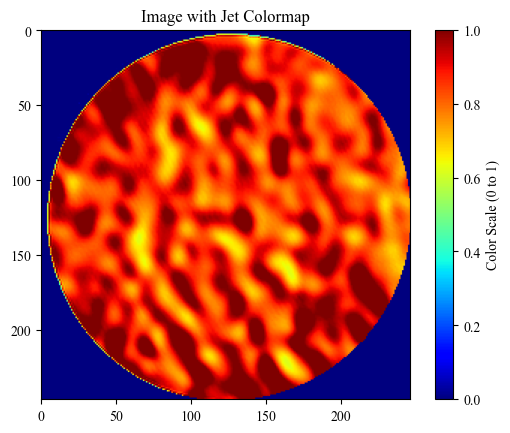

In [20]:
plt.imshow(total_final[20,5], cmap='jet', vmin=0, vmax=1)
plt.colorbar(label='Color Scale (0 to 1)')
plt.title('Image with Jet Colormap')
plt.show()

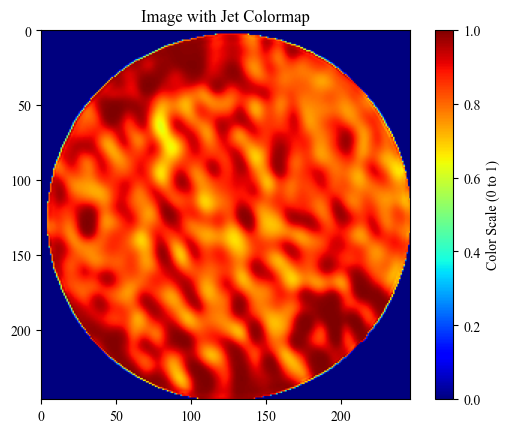

In [21]:
plt.imshow(preds[20,4], cmap='jet', vmin=0, vmax=1)
plt.colorbar(label='Color Scale (0 to 1)')
plt.title('Image with Jet Colormap')
plt.show()

In [22]:
from sklearn.metrics import r2_score
preds_r2=np.ones((64,10))

for i in range(0,64):
    for j in range(0,9):
        ss_res=np.sum((preds[i,j]-preds[i,j+1])**2)
        ss_tot=np.sum((preds[i,j]-preds[i,j].mean())**2)
        #tmp_r2=r2_score(total_final[i,j],total_final[i,j+1])
        tmp_r2=1-ss_res/ss_tot
        preds_r2[i,j+1]=tmp_r2

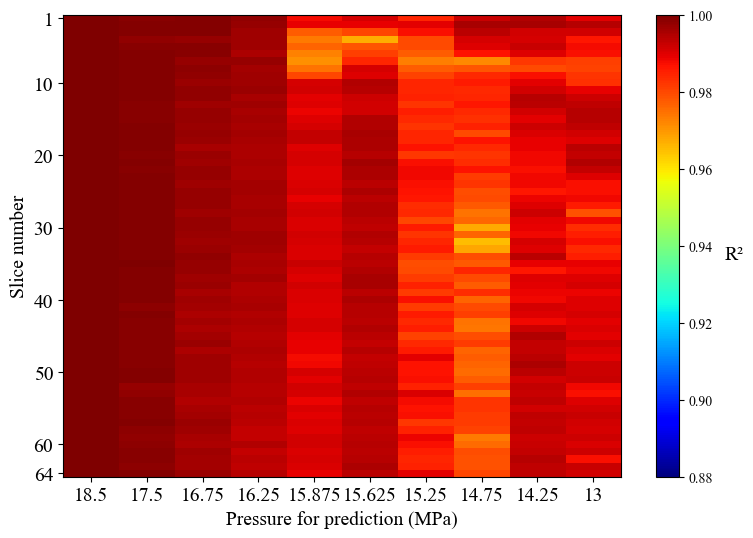

In [23]:
vmin=0.88

fig=plt.figure(figsize=(9, 6))
plt.imshow(preds_r2, cmap='jet',vmin=vmin, vmax=1,aspect='auto')
plt.xticks([0,1,2,3,4,5,6,7,8,9],fontsize=14,labels=['18.5', '17.5', '16.75', '16.25', '15.875', '15.625', '15.25', '14.75', '14.25', '13'])
plt.yticks([0,9,19,29,39,49,59,63],fontsize=14,labels=['1','10','20','30','40','50','60','64'])
plt.xlabel('Pressure for prediction (MPa)',fontsize=14)
plt.ylabel('Slice number',fontsize=14)
cbar = fig.colorbar(r2, ax=plt.gca())
cbar.ax.set_ylabel(f"R\u00b2",rotation=0,labelpad=15,loc='center',fontsize=14)
plt.savefig("r2_CTimages_only_predict", dpi=230)
plt.show()

plt.close(fig)

In [24]:
total_with_pred=[]

for i in range(0,64):
    tmp=[]
    #tmp.append(total_final[i,0]) #20
    #tmp.append(total_final[i,1]) #19
    #tmp.append(preds[i,0]) #18.5
    #tmp.append(total_final[i,2]) #18
    #tmp.append(preds[i,1]) #17.5
    #tmp.append(total_final[i,3]) #17
    #tmp.append(preds[i,2]) #16.75
    tmp.append(total_final[i,4]) #16.5
    tmp.append(preds[i,3]) #16.25
    tmp.append(total_final[i,5]) #16
    #tmp.append(preds[i,4]) #15.875
    tmp.append(total_final[i,6]) #15.75
    #tmp.append(preds[i,5]) #15.625
    tmp.append(total_final[i,7]) #15.5
    tmp.append(preds[i,6]) #15.25
    tmp.append(total_final[i,8]) #15
    tmp.append(preds[i,7]) #14.75
    tmp.append(total_final[i,9]) #14.5
    tmp.append(preds[i,8]) #14.25
    tmp.append(total_final[i,10]) #14
    tmp.append(preds[i,9]) #13
    tmp.append(total_final[i,11]) #12
    
    total_with_pred.append(tmp)

In [25]:
total_with_pred=np.array(total_with_pred)

In [26]:
total_with_pred_r2=np.ones((64,13))

for i in range(0,64):
    for j in range(0,12):
        ss_res=np.sum((total_with_pred[i,j]-total_with_pred[i,j+1])**2)
        ss_tot=np.sum((total_with_pred[i,j]-total_with_pred[i,j].mean())**2)
        tmp_r2=1-ss_res/ss_tot
        total_with_pred_r2[i,j+1]=tmp_r2

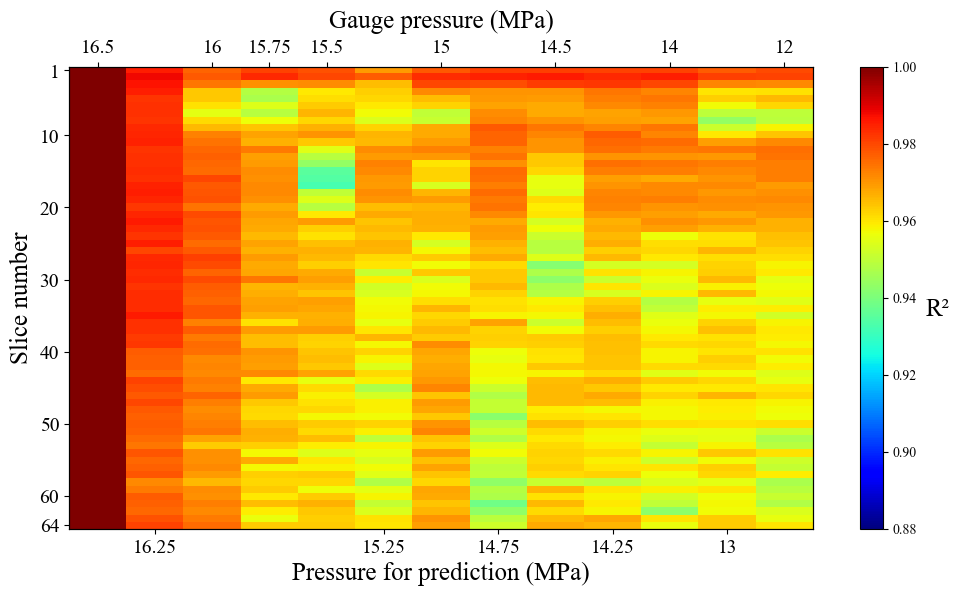

In [27]:

vmin=0.88
r2 = plt.cm.ScalarMappable(norm=colors.Normalize(vmin=vmin, vmax=1), cmap='jet')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(total_with_pred_r2, cmap='jet', vmin=vmin, vmax=1, aspect='auto')

# --- bottom x-axis (black labels) ---
bottom_pos = [1,5,7,9,11]
bottom_lbl = ['16.25', '15.25', '14.75', '14.25', '13']
ax.set_xticks(bottom_pos)
ax.set_xticklabels(bottom_lbl, fontsize=14, color='black')

# --- top x-axis (blue labels) ---
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())  # keep the same data scale as the bottom axis
top_pos = [0,2,3,4,6,8,10,12]
top_lbl = ['16.5', '16', '15.75', '15.5', '15', '14.5', '14', '12']
ax_top.set_xticks(top_pos)
ax_top.set_xticklabels(top_lbl, fontsize=14, color='black')
ax_top.set_xlabel('Gauge pressure (MPa)', fontsize=18, labelpad=8)
ax_top.tick_params(axis='x', top=True, labeltop=True)  # show at the top

# y-axis ticks
ax.set_yticks([0,9,19,29,39,49,59,63])
ax.set_yticklabels(['1','10','20','30','40','50','60','64'], fontsize=14)
ax.set_xlabel('Pressure for prediction (MPa)', fontsize=18)
ax.set_ylabel('Slice number', fontsize=18)
cbar = fig.colorbar(r2, ax=plt.gca())
cbar.ax.set_ylabel(f"R\u00b2",rotation=0,labelpad=15,loc='center',fontsize=18)
plt.savefig("r2_CTimages_together", dpi=230)
plt.show()

plt.close(fig)


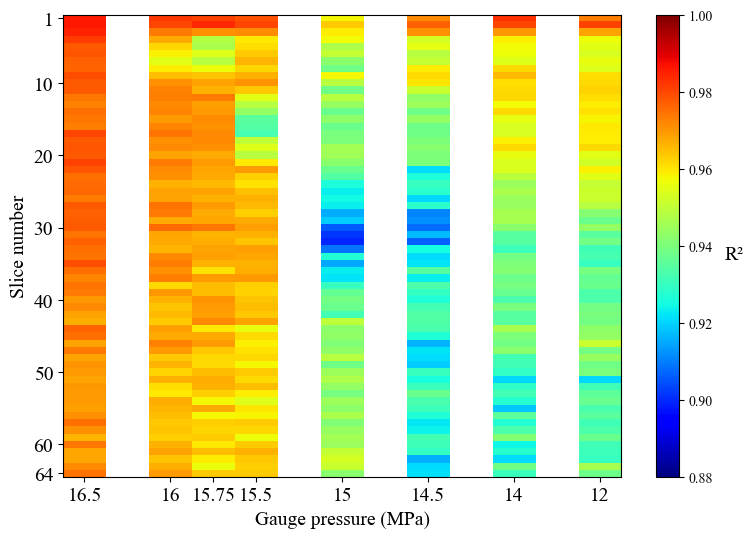

In [28]:
vmin = 0.88
selected_labels = ['16.5','16','15.75','15.5','15','14.5','14','12']
all_labels      = ['20','19','18','17','16.5','16','15.75','15.5','15','14.5','14','12']

# Adjacent labels that should have NO gap between them
nogap_cluster = {'16', '15.75', '15.5'}   # contiguous group

# colormap/norm with transparency for masked values
norm = colors.Normalize(vmin=vmin, vmax=1)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(alpha=0)  # masked -> transparent

# pick data columns to keep (by label)
sel_idx = [all_labels.index(lab) for lab in selected_labels]
data_sel = total_r2[:, sel_idx]    # shape (H, 8)

# build output with conditional gaps
gap_width = 1  # transparent columns inserted between groups
H, N = data_sel.shape
cols = []
data_xpos = []  # x positions for ticks at data columns
x = 0

for j in range(N):
    # add the data column
    cols.append(np.ma.array(data_sel[:, j:j+1], mask=False))
    data_xpos.append(x)
    x += 1

    # add a transparent gap unless both neighbors are in the nogap cluster
    if j < N - 1:
        a, b = selected_labels[j], selected_labels[j+1]
        if not (a in nogap_cluster and b in nogap_cluster):
            cols.append(np.ma.masked_all((H, gap_width)))
            x += gap_width

# concatenate to final image
out = np.ma.hstack(cols)

# --- plot ---
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()
im = ax.imshow(out, cmap=cmap, norm=norm, aspect='auto')
ax.set_facecolor('none')  # gaps show as transparent

# ticks: only at data columns
ax.set_xticks(data_xpos)
ax.set_xticklabels(selected_labels, fontsize=14)

# y-ticks (same as your original)
ax.set_yticks([0,9,19,29,39,49,59,63])
ax.set_yticklabels(['1','10','20','30','40','50','60','64'], fontsize=14)

ax.set_xlabel('Gauge pressure (MPa)', fontsize=14)
ax.set_ylabel('Slice number', fontsize=14)

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("R\u00b2", rotation=0, labelpad=15, loc='center', fontsize=14)
# cbar.ax.tick_params(labelsize=16)  # uncomment if you want bigger numbers

plt.savefig("r2_CTimages_selected_nogap_16_1575_155.png", dpi=230)  # add transparent=True for PNG transparency
plt.show()
plt.close(fig)

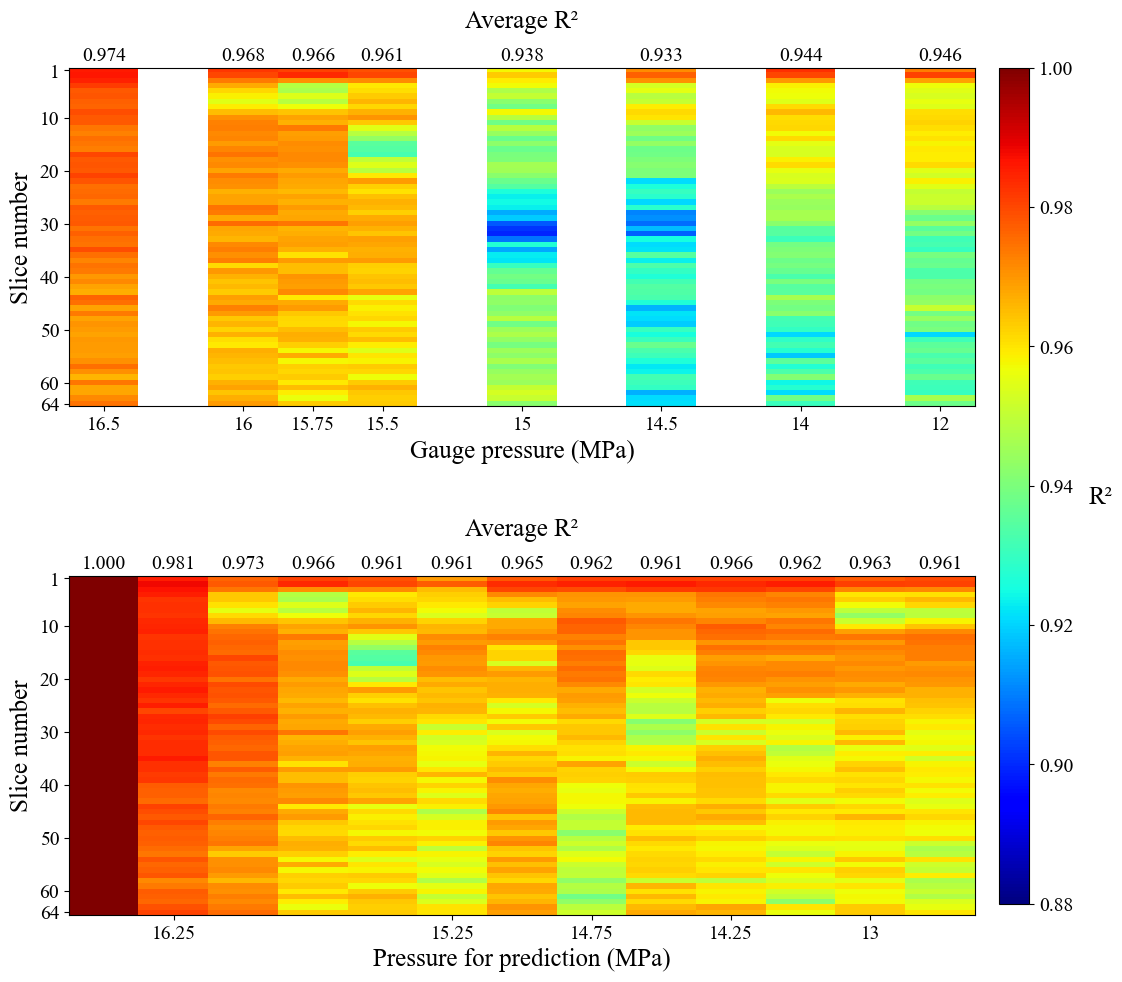

In [29]:

# ---------------- Common settings ----------------
vmin = 0.88
norm = colors.Normalize(vmin=vmin, vmax=1)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(alpha=0)  # masked values -> transparent

# ---------------- Row 1 (your original style) ----------------
# Data: total_with_pred_r2 (H x W)
bottom_pos = [1,5,7,9,11]
bottom_lbl = ['16.25', '15.25', '14.75', '14.25', '13']

top_pos = [0,2,3,4,6,8,10,12]
top_lbl = ['16.5', '16', '15.75', '15.5', '15', '14.5', '14', '12']

# ---------------- Row 2 (selected labels + conditional gaps) ----------------
# Data source for row 2: total_r2 (H x 12) with these labels:
all_labels      = ['20','19','18','17','16.5','16','15.75','15.5','15','14.5','14','12']
selected_labels = ['16.5','16','15.75','15.5','15','14.5','14','12']
sel_idx = [all_labels.index(lab) for lab in selected_labels]

# Make a view of only selected columns
data_sel = total_r2[:, sel_idx]  # shape (H, 8)

# Cluster with NO gap between neighbors:
nogap_cluster = {'16', '15.75', '15.5'}

# Build an output array with masked (transparent) columns as gaps,
# but no gaps inside the nogap_cluster
gap_width = 1  # columns of transparency between groups
H, N = data_sel.shape
cols = []
data_xpos = []   # x positions of real data columns for ticks
x = 0
for j in range(N):
    # data column
    cols.append(np.ma.array(data_sel[:, j:j+1], mask=False))
    data_xpos.append(x)
    x += 1
    # add gap unless both neighbors are in the nogap cluster
    if j < N - 1:
        a, b = selected_labels[j], selected_labels[j+1]
        if not (a in nogap_cluster and b in nogap_cluster):
            cols.append(np.ma.masked_all((H, gap_width), dtype=float))
            x += gap_width

out_row2 = np.ma.hstack(cols)  # final image for row 2

# ---------------- Figure layout ----------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 11), sharey=True,
    gridspec_kw={'height_ratios': [1, 1]}
)



# ---- Plot Row 1 ----
im1 = ax1.imshow(out_row2, cmap=cmap, norm=norm, aspect='auto')
ax1.set_facecolor('none')  # show gaps as transparent

# x ticks only at data columns (no ticks on the gap columns)
ax1.set_xticks(data_xpos)
ax1.set_xticklabels(selected_labels, fontsize=14, color='black')

col_means_row1 = np.nanmean(data_sel, axis=0)  # (H x 8) -> (8,)
for xpos, m in zip(data_xpos, col_means_row1):
    ax1.text(
        xpos, -1.0, f'{m:.3f}',
        ha='center', va='bottom', fontsize=14, color='black',
        clip_on=False,
        bbox=dict(facecolor='white', alpha=0.7, pad=1.5, edgecolor='none')
    )

# y ticks (shared with row 1)
ax1.set_yticks([0,9,19,29,39,49,59,63])
ax1.set_yticklabels(['1','10','20','30','40','50','60','64'], fontsize=14)

ax1.set_xlabel('Gauge pressure (MPa)', fontsize=18)
ax1.set_ylabel('Slice number', fontsize=18)

# ---- Plot Row 2 ----
im2 = ax2.imshow(total_with_pred_r2, cmap=cmap, norm=norm, aspect='auto')

H2, W2 = total_with_pred_r2.shape
col_means_row2 = np.nanmean(total_with_pred_r2, axis=0)  # (W2,)
# rotate labels if there are many columns to avoid clutter
rot = 90 if W2 >= 16 else 0
fs  = 14 if W2 >= 16 else 12
for x in range(W2):
    ax2.text(
        x, -1.0, f'{col_means_row2[x]:.3f}',
        ha='center', va='bottom', fontsize=14, rotation=rot, color='black',
        clip_on=False,
        bbox=dict(facecolor='white', alpha=0.7, pad=1.5, edgecolor='none')
    )

# bottom ticks (black)
ax2.set_xticks(bottom_pos)
ax2.set_xticklabels(bottom_lbl, fontsize=14, color='black')

# top ticks (black) via twin axis

# y ticks
ax2.set_yticks([0,9,19,29,39,49,59,63])
ax2.set_yticklabels(['1','10','20','30','40','50','60','64'], fontsize=14)

ax2.set_xlabel('Pressure for prediction (MPa)', fontsize=18)
ax2.set_ylabel('Slice number', fontsize=18)

# --- Overall average labels (one per subfigure) ---
avg_r2_row1 = np.nanmean(data_sel)              # row 1 uses only the real columns (no gaps)
avg_r2_row2 = np.nanmean(total_with_pred_r2)    # row 2 uses the full matrix

ax1.text(
    0.5, 1.1, f'Average R\u00b2',
    transform=ax1.transAxes, ha='center', va='bottom',
    fontsize=18,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)
ax2.text(
    0.5, 1.1, f'Average R\u00b2',
    transform=ax2.transAxes, ha='center', va='bottom',
    fontsize=18, 
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)
# ---------------- Shared, larger colorbar ----------------
# Add a dedicated axis for a big vertical colorbar spanning both rows
fig.subplots_adjust(right=0.88, hspace=0.50)
cax = fig.add_axes([0.90, 0.12, 0.025, 0.76])  # [left, bottom, width, height]
# Either im1 or im2 is fine since they share cmap/norm
cbar = fig.colorbar(im1, cax=cax, orientation='vertical')
cbar.ax.set_ylabel("R\u00b2", rotation=0, labelpad=20, fontsize=18)
cbar.ax.tick_params(labelsize=14)

plt.savefig("r2_two_rows_one_figure.png", dpi=230)
plt.show()
plt.close(fig)

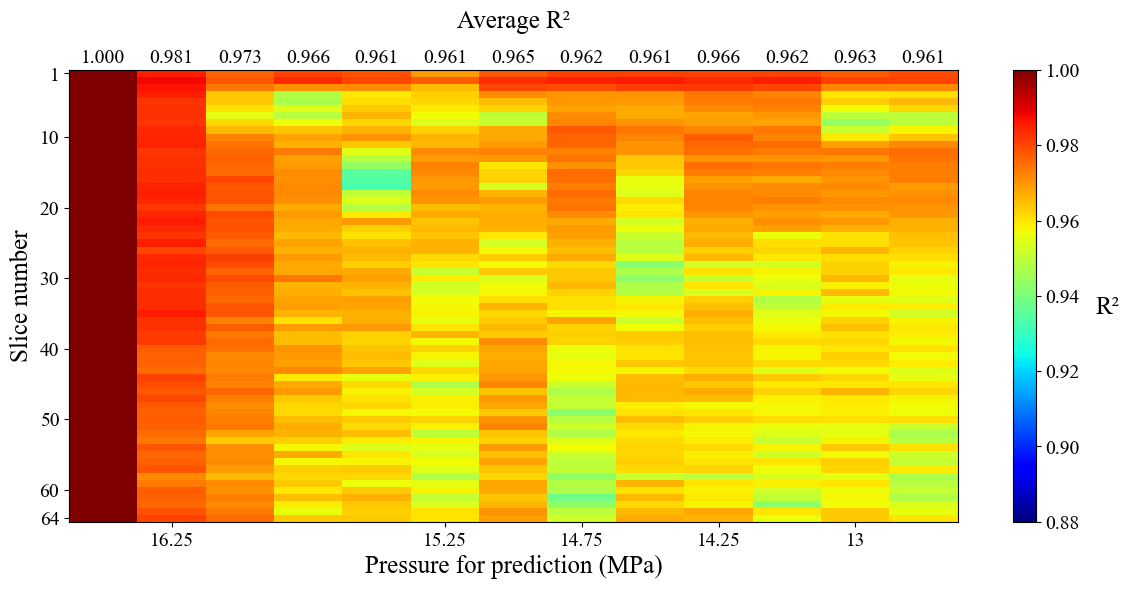

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# ---------- Data you must already have ----------
# total_with_pred_r2: 2D array (H x W) of R^2 values
# Example (remove these two lines when using real data):
# H, W = 64, 13
# total_with_pred_r2 = np.random.uniform(0.88, 1.0, (H, W))

# Tick positions/labels (from your original code)
bottom_pos = [1,5,7,9,11]
bottom_lbl = ['16.25', '15.25', '14.75', '14.25', '13']

top_pos = [0,2,3,4,6,8,10,12]
top_lbl = ['16.5', '16', '15.75', '15.5', '15', '14.5', '14', '12']

# ---------- Common settings ----------
vmin = 0.88
norm = colors.Normalize(vmin=vmin, vmax=1)
cmap = plt.colormaps['jet'].copy()
cmap.set_bad(alpha=0)  # masked values -> transparent

# ---------- Figure (single subplot) ----------
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Heatmap
im = ax.imshow(total_with_pred_r2, cmap=cmap, norm=norm, aspect='auto')

# Per-column mean labels above the image
H2, W2 = total_with_pred_r2.shape
col_means = np.nanmean(total_with_pred_r2, axis=0)  # (W2,)
rot = 90 if W2 >= 16 else 0

for x in range(W2):
    ax.text(
        x, -1.0, f'{col_means[x]:.3f}',
        ha='center', va='bottom', fontsize=14, rotation=rot, color='black',
        clip_on=False,
        bbox=dict(facecolor='white', alpha=0.7, pad=1.5, edgecolor='none')
    )

# Bottom ticks (black)
ax.set_xticks(bottom_pos)
ax.set_xticklabels(bottom_lbl, fontsize=14, color='black')

# Top ticks (black) via twin axis
#ax_top = ax.twiny()
#ax_top.set_xlim(ax.get_xlim())
#ax_top.set_xticks(top_pos)
#ax_top.set_xticklabels(top_lbl, fontsize=14, color='black')
#ax_top.tick_params(axis='x', which='both', pad=4)

# Y ticks
ax.set_yticks([0,9,19,29,39,49,59,63])
ax.set_yticklabels(['1','10','20','30','40','50','60','64'], fontsize=14)

# Labels and title-ish average tag
ax.set_xlabel('Pressure for prediction (MPa)', fontsize=18)
ax.set_ylabel('Slice number', fontsize=18)

avg_r2 = np.nanmean(total_with_pred_r2)
ax.text(
    0.5, 1.08, f'Average R\u00b2',
    transform=ax.transAxes, ha='center', va='bottom',
    fontsize=18,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("R\u00b2", rotation=0, labelpad=20, fontsize=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig("r2_row2_only.png", dpi=230, bbox_inches='tight')
plt.show()
plt.close(fig)
